In [1]:
import json
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymutspec.annotation import rev_comp
from pymutspec.constants import possible_sbs192, possible_codons
from pymutspec.draw import plot_mutspec192
import SigProfilerAssignment
from SigProfilerAssignment import Analyzer as Analyze
from scipy.stats import spearmanr

from utils import sbs2effect, collapse_sbs192, complete_sbs_columns

In [2]:
# version of SigProfilerAssignment
SigProfilerAssignment.__version__

'0.2.3'

In [ ]:
# funcs for specific data processing and writing


def read_human_triplet_counts(include_lower_nucls=False):
    with open("./data/triplet_counts_GRCh37.json") as fin:
        _human_counts_raw = json.load(fin)
        if include_lower_nucls:
            human_counts = defaultdict(int)
            for triplet, n in _human_counts_raw.items():
                human_counts[triplet.upper()] += n
            human_counts = dict(human_counts)        
        else:
            # without aAa, tAA, tgc etc. Only upper case
            _human_counts_raw = {x: _human_counts_raw[x] for x in possible_codons}
            human_counts = defaultdict(int)
            for triplet, n in _human_counts_raw.items():
                human_counts[triplet.upper()] += n
            human_counts = dict(human_counts)
        return human_counts

In [5]:
possible_sbs6 = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
possible_sbs96 = [x for x in possible_sbs192 if x[2:5] in possible_sbs6]
print(possible_sbs96)

['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'C[C>A]A', 'C[C>A]C', 'C[C>A]G', 'C[C>A]T', 'G[C>A]A', 'G[C>A]C', 'G[C>A]G', 'G[C>A]T', 'T[C>A]A', 'T[C>A]C', 'T[C>A]G', 'T[C>A]T', 'A[C>G]A', 'A[C>G]C', 'A[C>G]G', 'A[C>G]T', 'C[C>G]A', 'C[C>G]C', 'C[C>G]G', 'C[C>G]T', 'G[C>G]A', 'G[C>G]C', 'G[C>G]G', 'G[C>G]T', 'T[C>G]A', 'T[C>G]C', 'T[C>G]G', 'T[C>G]T', 'A[C>T]A', 'A[C>T]C', 'A[C>T]G', 'A[C>T]T', 'C[C>T]A', 'C[C>T]C', 'C[C>T]G', 'C[C>T]T', 'G[C>T]A', 'G[C>T]C', 'G[C>T]G', 'G[C>T]T', 'T[C>T]A', 'T[C>T]C', 'T[C>T]G', 'T[C>T]T', 'A[T>A]A', 'A[T>A]C', 'A[T>A]G', 'A[T>A]T', 'C[T>A]A', 'C[T>A]C', 'C[T>A]G', 'C[T>A]T', 'G[T>A]A', 'G[T>A]C', 'G[T>A]G', 'G[T>A]T', 'T[T>A]A', 'T[T>A]C', 'T[T>A]G', 'T[T>A]T', 'A[T>C]A', 'A[T>C]C', 'A[T>C]G', 'A[T>C]T', 'C[T>C]A', 'C[T>C]C', 'C[T>C]G', 'C[T>C]T', 'G[T>C]A', 'G[T>C]C', 'G[T>C]G', 'G[T>C]T', 'T[T>C]A', 'T[T>C]C', 'T[T>C]G', 'T[T>C]T', 'A[T>G]A', 'A[T>G]C', 'A[T>G]G', 'A[T>G]T', 'C[T>G]A', 'C[T>G]C', 'C[T>G]G', 'C[T>G]T', 'G[T>G]A', 'G[T>G]C', 'G[T>G]G'

In [41]:
# Load and prepare spectra data
species_spectra = pd.read_csv('../1data_derivation/dataset/MutSpecVertebrates192.csv.gz')
species_spectra = species_spectra[species_spectra.Gene == 'Cytb']
species_spectra['Mut'] = species_spectra['Mut'].apply(rev_comp) # to H-strand notation
species_spectra['Label'] = species_spectra['Class'] + '__' + species_spectra['Species']

print(species_spectra.Species.nunique(), 'species')
species_spectra.head()

1697 species


,Gene,Class,Species,Mut,Observed,Expected,MutSpec,Label
39552,Cytb,Mammalia,Tarsius_dentatus,T[T>G]T,NaN,0.00,0.0,Mammalia__Tarsius_dentatus
39553,Cytb,Mammalia,Tarsius_dentatus,G[T>G]T,NaN,0.00,0.0,Mammalia__Tarsius_dentatus
39554,Cytb,Mammalia,Tarsius_dentatus,C[T>G]T,NaN,0.00,0.0,Mammalia__Tarsius_dentatus
39555,Cytb,Mammalia,Tarsius_dentatus,A[T>G]T,NaN,0.00,0.0,Mammalia__Tarsius_dentatus
39556,Cytb,Mammalia,Tarsius_dentatus,T[T>G]G,NaN,11.95,0.0,Mammalia__Tarsius_dentatus


In [7]:
# check most popular sbs - we see C>T, therefore we are using H-strand 
species_spectra.groupby('Mut').MutSpec.mean().sort_values()

Mut
A[A>C]T    0.000000
A[A>T]T    0.000000
A[C>A]T    0.000000
A[C>G]T    0.000000
A[G>C]T    0.000000
             ...   
A[C>T]T    0.028516
A[C>T]A    0.029996
G[C>T]C    0.031454
A[C>T]C    0.039361
C[C>T]C    0.043280
Name: MutSpec, Length: 192, dtype: float64

In [51]:
species_spectra_wide = complete_sbs_columns(
    species_spectra.pivot(index="Label", columns="Mut", values="MutSpec"), 192)

species_spectra_wide96 = collapse_sbs192(species_spectra_wide, 96)
species_spectra_wide96

Mut,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
Label,,,,,,,,,,,,,,,,,,,,,
Actinopteri__Abbottina_rivularis,0.0,0.0,0.026751,0.0,0.046290,0.011904,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.00000,0.000000,0.011662,0.0,0.000000,0.0,0.0,0.0
Actinopteri__Acanthopagrus_latus,0.0,0.0,0.000000,0.0,0.008164,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
Actinopteri__Acanthopagrus_taiwanensis,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
Actinopteri__Acentrogobius_janthinopterus,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.00000,0.039911,0.000000,0.0,0.000000,0.0,0.0,0.0
Actinopteri__Acheilognathus_barbatulus,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.104889,...,0.000000,0.0,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mammalia__Xerus_inauris,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.003759,0.0,0.00000,0.000000,0.006992,0.0,0.003504,0.0,0.0,0.0
Mammalia__Zapus_hudsonius,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.00866,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
Mammalia__Zapus_princeps,0.0,0.0,0.000000,0.0,0.012607,0.002094,0.009745,0.000000,0.0,0.000000,...,0.000000,0.0,0.00000,0.000000,0.029441,0.0,0.000000,0.0,0.0,0.0


In [52]:
species_spectra_wide96.sum(1).min()

0.9999999999999951

### Save spectra in required format

In [70]:
# we can use any subsample of human genome to calculate trinucl freqs and we will give 
# same results due to too big counts of trinucleotides (data not shown but precicely checked)
human_counts = read_human_triplet_counts(include_lower_nucls=False)

df = species_spectra_wide96[possible_sbs96].copy()
df.columns.name = "MutationType"
multiplier = df.columns.to_series().apply(lambda x: x[0] + x[2] + x[-1]).map(human_counts)
rescaled = (df * multiplier).T
rescaled /= rescaled.sum()
rescaled = rescaled * species_spectra.groupby(['Label']).Observed.sum()
rescaled_int = rescaled.apply(np.ceil).astype(int)

filename = "./data/SigProfilerAssignment/input2/samples.txt"
rescaled_int.sort_index().to_csv(filename, sep="\t")
rescaled_int

Label,Actinopteri__Abbottina_rivularis,Actinopteri__Acanthopagrus_latus,Actinopteri__Acanthopagrus_taiwanensis,Actinopteri__Acentrogobius_janthinopterus,Actinopteri__Acheilognathus_barbatulus,Actinopteri__Acheilognathus_chankaensis,Actinopteri__Acheilognathus_macropterus,Actinopteri__Acheilognathus_melanogaster,Actinopteri__Acheilognathus_rhombeus,Actinopteri__Acheilognathus_tabira,...,Mammalia__Vampyressa_pusilla,Mammalia__Vernaya_fulva,Mammalia__Vulpes_lagopus,Mammalia__Vulpes_vulpes,Mammalia__Xerospermophilus_tereticaudus,Mammalia__Xerus_inauris,Mammalia__Zapus_hudsonius,Mammalia__Zapus_princeps,Mammalia__Zapus_trinotatus,Mammalia__Ziphius_cavirostris
MutationType,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A[C>A]C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A[C>A]G,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A[C>A]T,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C[C>A]A,3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G[T>G]T,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T[T>G]A,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
T[T>G]C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Decompose

In [74]:
# Run sigprofiller cosmic_fit func to decompose chordates classes spcectra to COSMIC signatures
# Run on several different spectra types (Low, High, Diff) separately

# 10 minutes per run

samples = "./data/SigProfilerAssignment/input2/samples.txt"
output = "./data/SigProfilerAssignment/output2/"

exclude_signature_subgroups = [
    'Artifact_signatures',
    'Immunosuppressants_signatures',
    'Treatment_signatures',
    'Lymphoid_signatures',
    'Colibactin_signatures',
    'AA_signatures',
]

Analyze.cosmic_fit(samples, output, input_type="matrix", context_type="96",
                cosmic_version=3.3, exome=False,
                nnls_remove_penalty=0.01, nnls_add_penalty = 0.02,
                exclude_signature_subgroups=exclude_signature_subgroups, 
                export_probabilities=False, make_plots=True,
                sample_reconstruction_plots=False, verbose=False)

The following signatures are excluded: SBS32 SBS11 SBS25 SBS31 SBS32 SBS35 SBS86 SBS87 SBS90 SBS99 SBS22 SBS22a SBS22b SBS88 SBS27 SBS43 SBS45 SBS46 SBS47 SBS48 SBS49 SBS50 SBS51 SBS52 SBS53 SBS54 SBS55 SBS56 SBS57 SBS58 SBS59 SBS60 SBS95 SBS9 SBS84 SBS85
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


## Analyse activities

In [3]:
p = './data/SigProfilerAssignment/output2/Assignment_Solution/Activities/Assignment_Solution_Activities.txt'
act = pd.read_csv(p, sep='\t', index_col=0)

p = './data/SigProfilerAssignment/output2/Assignment_Solution/Solution_Stats/Assignment_Solution_Samples_Stats.txt'
stats = pd.read_csv(p, sep='\t', index_col=0)

In [4]:
stats['L1_Norm_%'] = stats['L1 Norm'] / stats['Total Mutations'] * 100

In [32]:
stats.head()

,Total Mutations,Cosine Similarity,L1 Norm,L1_Norm_%,L2 Norm,L2_Norm_%,KL Divergence,Correlation
Sample Names,,,,,,,,
Actinopteri__Abbottina_rivularis,55,0.449,64.202,116.730909,15.254,89.729%,1.36674,0.329
Actinopteri__Acanthopagrus_latus,84,0.773,60.127,71.579762,11.693,63.602%,0.53208,0.699
Actinopteri__Acanthopagrus_taiwanensis,30,0.609,35.670,118.900000,8.590,79.756%,1.00033,0.564
Actinopteri__Acentrogobius_janthinopterus,43,0.681,41.648,96.855814,8.333,73.368%,0.96173,0.608
Actinopteri__Acheilognathus_barbatulus,31,0.628,36.770,118.612903,8.133,77.9%,1.24812,0.578


Text(0.5, 0, 'Decomposition Cosine Similarity')

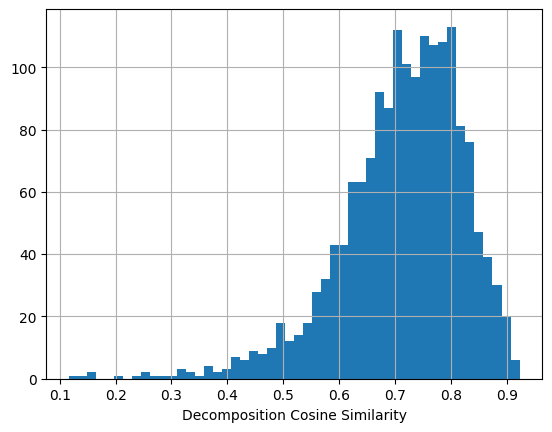

In [37]:
stats['Cosine Similarity'].hist(bins=50)
plt.xlabel('Decomposition Cosine Similarity')

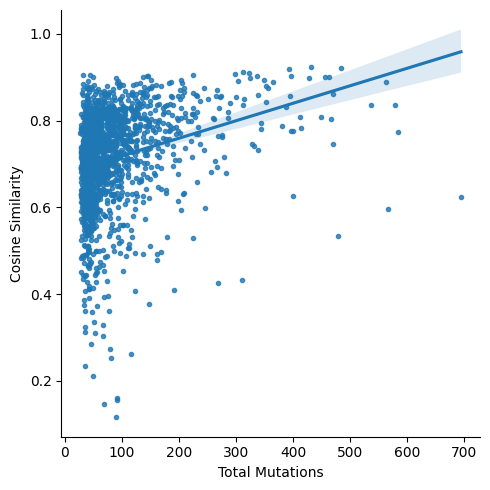

In [34]:
sns.lmplot(stats, x='Total Mutations', y='Cosine Similarity', markers='.', order=1)

In [5]:
valid_ids = stats[stats['Cosine Similarity'] > 0.65].index

In [6]:
act_flt = act.loc[valid_ids]
sbs_act = (act_flt>0).sum()
act_flt = act_flt[sbs_act[sbs_act>=50].index]

In [7]:
act_flt_frac = (act_flt.T / act_flt.sum(1)).T
act_flt_frac

,SBS1,SBS2,SBS5,SBS7a,SBS7b,SBS7d,SBS10a,SBS12,SBS16,SBS17a,SBS19,SBS21,SBS23,SBS26,SBS30,SBS33,SBS37,SBS42,SBS44
Sample Names,,,,,,,,,,,,,,,,,,,
Actinopteri__Acanthopagrus_latus,0.071429,0.000000,0.000000,0.0,0.0,0.0,0.00,0.369048,0.0,0.083333,0.00000,0.0,0.000000,0.0,0.154762,0.0,0.0,0.321429,0.00
Actinopteri__Acentrogobius_janthinopterus,0.023256,0.000000,0.232558,0.0,0.0,0.0,0.00,0.465116,0.0,0.000000,0.27907,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.00
Actinopteri__Acheilognathus_chankaensis,0.000000,0.155172,0.000000,0.0,0.0,0.0,0.00,0.603448,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.241379,0.0,0.0,0.000000,0.00
Actinopteri__Acheilognathus_macropterus,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00,0.545455,0.0,0.181818,0.00000,0.0,0.272727,0.0,0.000000,0.0,0.0,0.000000,0.00
Actinopteri__Acheilognathus_melanogaster,0.080000,0.000000,0.000000,0.0,0.0,0.0,0.16,0.400000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.360000,0.0,0.0,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mammalia__Xerus_inauris,0.026667,0.000000,0.013333,0.0,0.0,0.0,0.00,0.386667,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.573333,0.0,0.0,0.000000,0.00
Mammalia__Zapus_hudsonius,0.000000,0.104000,0.280000,0.0,0.0,0.0,0.00,0.256000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.36
Mammalia__Zapus_princeps,0.000000,0.000000,0.708772,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.291228,0.0,0.0,0.000000,0.00


Text(0, 0.5, 'Fraction in species')

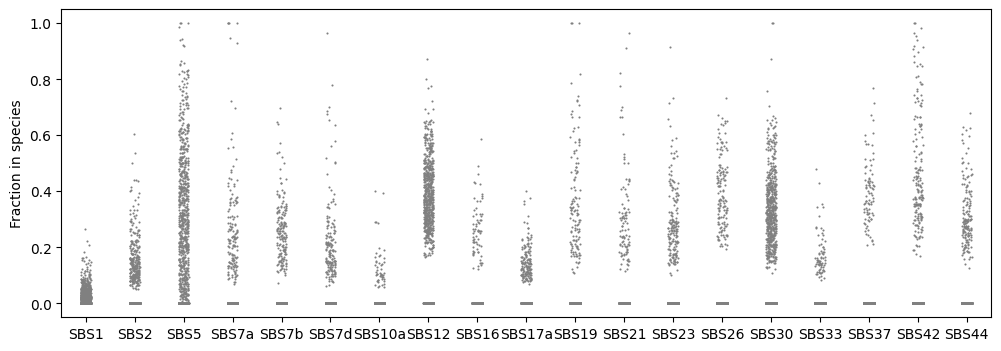

In [83]:
plt.figure(figsize=(12, 4))
sns.stripplot(act_flt_frac, log_scale=False, color='gray', size=1.5)
plt.ylabel('Fraction in species')

In [8]:
act_flt_frac['Class'] = act_flt_frac.index.to_series().apply(lambda x: x.split('__')[0])

In [9]:
act_flt_frac_long = act_flt_frac.reset_index()\
    .melt(['Class', 'Sample Names'], act_flt_frac.columns[:-1])
act_flt_frac_long.head()

,Class,Sample Names,variable,value
0,Actinopteri,Actinopteri__Acanthopagrus_latus,SBS1,0.071429
1,Actinopteri,Actinopteri__Acentrogobius_janthinopterus,SBS1,0.023256
2,Actinopteri,Actinopteri__Acheilognathus_chankaensis,SBS1,0.000000
3,Actinopteri,Actinopteri__Acheilognathus_macropterus,SBS1,0.000000
4,Actinopteri,Actinopteri__Acheilognathus_melanogaster,SBS1,0.080000


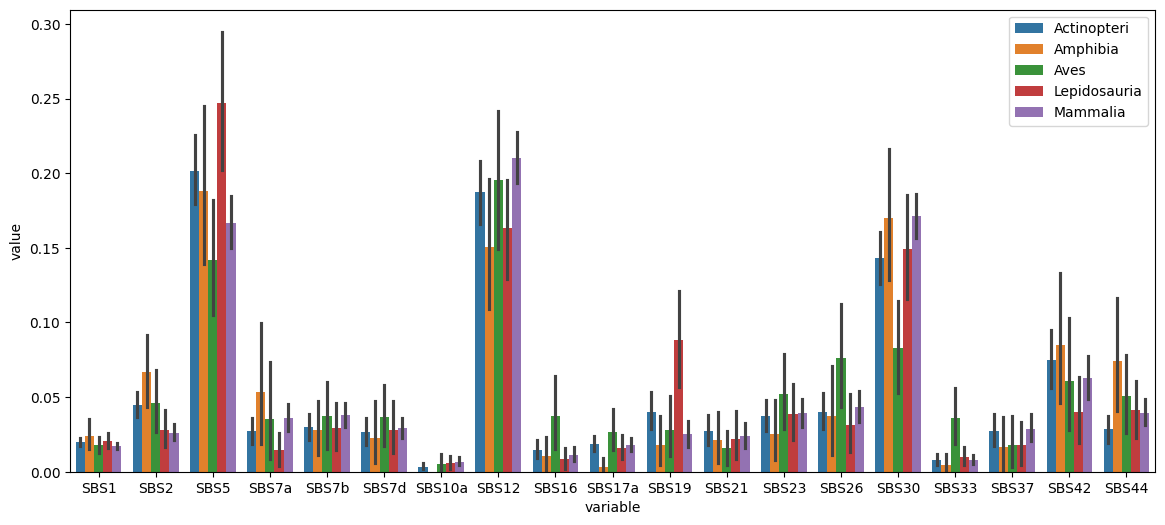

In [42]:
plt.figure(figsize=(14, 6))
sns.barplot(data=act_flt_frac_long, x='variable', y='value', hue='Class')
plt.legend(loc='upper right')

Text(0.5, 0, '')

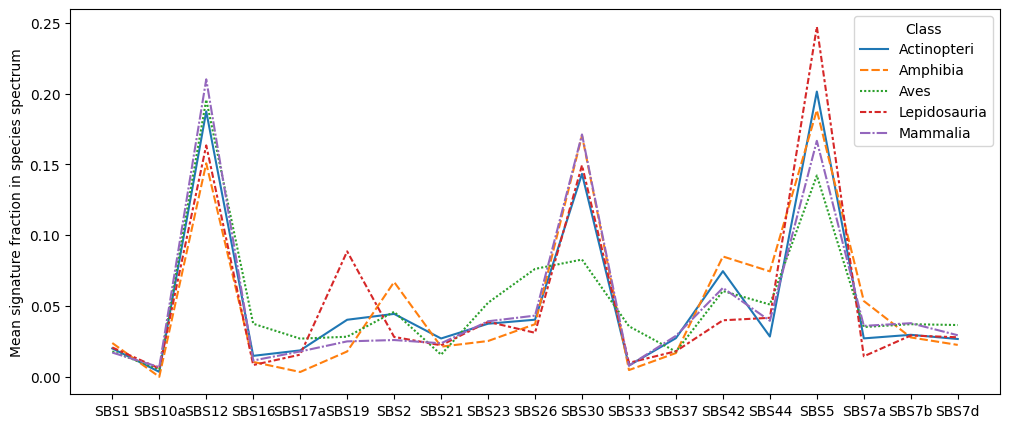

In [110]:
act_cls_mean = act_flt_frac_long.groupby(['Class', 'variable']).value.mean().unstack()

plt.figure(figsize=(12, 5))
sns.lineplot(act_cls_mean.T)
plt.ylabel('Mean signature fraction in species spectrum')
plt.xlabel('')

In [11]:
act_flt_frac

,SBS1,SBS2,SBS5,SBS7a,SBS7b,SBS7d,SBS10a,SBS12,SBS16,SBS17a,SBS19,SBS21,SBS23,SBS26,SBS30,SBS33,SBS37,SBS42,SBS44,Class
Sample Names,,,,,,,,,,,,,,,,,,,,
Actinopteri__Acanthopagrus_latus,0.071429,0.000000,0.000000,0.0,0.0,0.0,0.00,0.369048,0.0,0.083333,0.00000,0.0,0.000000,0.0,0.154762,0.0,0.0,0.321429,0.00,Actinopteri
Actinopteri__Acentrogobius_janthinopterus,0.023256,0.000000,0.232558,0.0,0.0,0.0,0.00,0.465116,0.0,0.000000,0.27907,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.00,Actinopteri
Actinopteri__Acheilognathus_chankaensis,0.000000,0.155172,0.000000,0.0,0.0,0.0,0.00,0.603448,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.241379,0.0,0.0,0.000000,0.00,Actinopteri
Actinopteri__Acheilognathus_macropterus,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00,0.545455,0.0,0.181818,0.00000,0.0,0.272727,0.0,0.000000,0.0,0.0,0.000000,0.00,Actinopteri
Actinopteri__Acheilognathus_melanogaster,0.080000,0.000000,0.000000,0.0,0.0,0.0,0.16,0.400000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.360000,0.0,0.0,0.000000,0.00,Actinopteri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mammalia__Xerus_inauris,0.026667,0.000000,0.013333,0.0,0.0,0.0,0.00,0.386667,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.573333,0.0,0.0,0.000000,0.00,Mammalia
Mammalia__Zapus_hudsonius,0.000000,0.104000,0.280000,0.0,0.0,0.0,0.00,0.256000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.36,Mammalia
Mammalia__Zapus_princeps,0.000000,0.000000,0.708772,0.0,0.0,0.0,0.00,0.000000,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.291228,0.0,0.0,0.000000,0.00,Mammalia


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import eli5
from eli5 import explain_weights_df

# Train/test split, fit linear classifier, evaluate and explain (uses eli5 if available, else permutation / coef fallback)


# prepare data (drop rows with missing feature values)
features = act_flt_frac.columns.drop('Class')
X = act_flt_frac[features].dropna(axis=0)
y = act_flt_frac.loc[X.index, 'Class']

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# pipeline: scaling + logistic regression (multinomial)
# clf = make_pipeline(
    # StandardScaler(),
    # LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, C=1.0, random_state=42)
# )
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, C=1.0, random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# basic evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix (optionally inspect)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix shape:", cm.shape)

# Try to explain classifier with eli5; fallback to coefficient inspection and permutation importance
feature_names = list(features)

try:
    # get underlying logistic regression estimator
    lr = clf
    df_w = explain_weights_df(lr, feature_names=feature_names, top=20, target_names=le.classes_)
    print("\nTop feature weights (eli5 explain_weights_df):")
    display(df_w)  # in notebook this will render nicely
except Exception as e:
    print("\neli5 not available or failed (exception: {}). Falling back to coef / permutation importance.".format(e))
    # Coefficient-based importances per class (top positive features)
    lr = clf
    coefs = lr.coef_  # shape (n_classes, n_features) for multinomial
    coef_df = pd.DataFrame(coefs, index=le.classes_, columns=feature_names)
    print("\nTop positive coefficients per class:")
    for cls in coef_df.index:
        top = coef_df.loc[cls].sort_values(ascending=False).head(10)
        print(f"\nClass: {cls}")
        print(top.to_string())

    # Permutation importance on test set
    r = permutation_importance(clf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
    perm_df = pd.Series(r.importances_mean, index=feature_names).sort_values(ascending=False)
    print("\nTop features by permutation importance (mean decrease):")
    print(perm_df.head(15).to_string())

Accuracy: 0.4710

Classification report:
              precision    recall  f1-score   support

 Actinopteri       0.32      0.09      0.14        81
    Amphibia       0.00      0.00      0.00        13
        Aves       0.00      0.00      0.00        18
Lepidosauria       0.00      0.00      0.00        26
    Mammalia       0.49      0.95      0.64       121

    accuracy                           0.47       259
   macro avg       0.16      0.21      0.16       259
weighted avg       0.33      0.47      0.34       259


Confusion matrix shape: (5, 5)

Top feature weights (eli5 explain_weights_df):


,target,feature,weight
0,Actinopteri,<BIAS>,0.841151
1,Actinopteri,SBS2,0.612728
2,Actinopteri,SBS37,0.418864
3,Actinopteri,SBS21,0.370542
4,Actinopteri,SBS7a,0.332715
...,...,...,...
95,Mammalia,SBS44,-0.269498
96,Mammalia,SBS33,-0.482581
97,Mammalia,SBS19,-0.603939
98,Mammalia,SBS1,-0.673885


In [45]:
df_w.pivot(index='target', columns='feature', values='weight')

feature,<BIAS>,SBS1,SBS10a,SBS12,SBS16,SBS17a,SBS19,SBS2,SBS21,SBS23,SBS26,SBS30,SBS33,SBS37,SBS42,SBS44,SBS5,SBS7a,SBS7b,SBS7d
target,,,,,,,,,,,,,,,,,,,,
Actinopteri,0.841151,0.171453,-0.355361,-0.060220,0.214243,0.080394,0.061915,0.612728,0.370542,-0.106656,-0.420574,0.006823,-0.419988,0.418864,0.315174,-0.821059,0.057708,0.332715,-0.117327,-0.280418
Amphibia,-1.006098,0.342216,-0.248368,-0.662730,-0.225343,-0.628113,-0.573510,1.148691,-0.185446,-0.290741,-0.281557,0.698665,-0.342045,-0.269832,0.521201,1.032504,-0.095263,0.465589,-0.363908,-0.127917
Aves,-0.474368,-0.177363,-0.146943,0.452135,0.292905,0.723104,-0.538272,-0.052099,-0.436857,0.187487,1.231461,-1.553239,1.458786,-0.527549,-0.284813,0.489790,-0.689077,-0.428732,-0.165144,0.142325
Lepidosauria,-0.489566,0.337579,0.042565,-0.262494,-0.146927,-0.222426,1.653806,-0.673773,0.061934,0.370370,-0.484780,0.385187,-0.214173,-0.349981,-0.494819,-0.431737,0.838152,-0.802868,0.217847,0.137725
Mammalia,1.128881,-0.673885,0.708107,0.533309,-0.134878,0.047041,-0.603939,-1.035546,0.189827,-0.160460,-0.044550,0.462564,-0.482581,0.728498,-0.056742,-0.269498,-0.111520,0.433296,0.428531,0.128284


In [56]:
clf.intercept_

array([ 0.84115053, -1.00609775, -0.4743683 , -0.4895659 ,  1.12888141])

In [55]:
pd.DataFrame(clf.coef_, columns=features, index=le.classes_)

,SBS1,SBS2,SBS5,SBS7a,SBS7b,SBS7d,SBS10a,SBS12,SBS16,SBS17a,SBS19,SBS21,SBS23,SBS26,SBS30,SBS33,SBS37,SBS42,SBS44
Actinopteri,0.171453,0.612728,0.057708,0.332715,-0.117327,-0.280418,-0.355361,-0.060220,0.214243,0.080394,0.061915,0.370542,-0.106656,-0.420574,0.006823,-0.419988,0.418864,0.315174,-0.821059
Amphibia,0.342216,1.148691,-0.095263,0.465589,-0.363908,-0.127917,-0.248368,-0.662730,-0.225343,-0.628113,-0.573510,-0.185446,-0.290741,-0.281557,0.698665,-0.342045,-0.269832,0.521201,1.032504
Aves,-0.177363,-0.052099,-0.689077,-0.428732,-0.165144,0.142325,-0.146943,0.452135,0.292905,0.723104,-0.538272,-0.436857,0.187487,1.231461,-1.553239,1.458786,-0.527549,-0.284813,0.489790
Lepidosauria,0.337579,-0.673773,0.838152,-0.802868,0.217847,0.137725,0.042565,-0.262494,-0.146927,-0.222426,1.653806,0.061934,0.370370,-0.484780,0.385187,-0.214173,-0.349981,-0.494819,-0.431737
Mammalia,-0.673885,-1.035546,-0.111520,0.433296,0.428531,0.128284,0.708107,0.533309,-0.134878,0.047041,-0.603939,0.189827,-0.160460,-0.044550,0.462564,-0.482581,0.728498,-0.056742,-0.269498
